# sklearn regression workflow cheat sheet

**What's in here**
- Features from timestamps and weather (no lags yet)
- Chronological train/test split (and why not `train_test_split(shuffle=True)`)
- `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`
- Metrics: RMSE, MAE, R², MAPE (and where MAPE breaks)
- Coefficient tables, intercept
- Hour as number vs one-hot; interactions; `PolynomialFeatures`
- Results table across models
- Baselines: `DummyRegressor` and "same hour yesterday" - the model must beat them
- Residual diagnostics: by hour, by month, autocorrelation, vs fitted
- One non-linear comparison (`RandomForestRegressor`, `GradientBoostingRegressor`) + `permutation_importance`
- What to say when R² looks too good

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120); pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).sort_values("time").reset_index(drop=True)
df["hour"]    = df["time"].dt.hour
df["dow"]     = df["time"].dt.dayofweek
df["month"]   = df["time"].dt.month
df["weekend"] = (df["dow"] >= 5).astype(int)
df["hdd"]     = np.clip(15 - df["temp_c"], 0, None)      # heating degrees
df["cdd"]     = np.clip(df["temp_c"] - 22, 0, None)      # cooling degrees
print(df.shape); df.head(3)

(17520, 12)


,time,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh,hour,dow,month,weekend,hdd,cdd
0,2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83,0,5,1,1,14.89,0.0
1,2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21,1,5,1,1,15.18,0.0
2,2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71,2,5,1,1,16.11,0.0


## Feature matrix and target

Keep the feature list in a variable and reuse it everywhere - the most common notebook bug is fitting on one set of columns and predicting on another.

In [2]:
target = "consumption_mwh"
features = ["hour", "dow", "month", "weekend", "temp_c", "hdd", "cdd", "wind_ms", "solar_wm2"]
X = df[features]; y = df[target]
print("any NaN in X:", X.isna().any().any(), " | in y:", y.isna().any())
X.describe().round(1).T

any NaN in X: False  | in y: False


,count,mean,std,min,25%,50%,75%,max
hour,17520.0,11.5,6.9,0.0,5.8,11.5,17.2,23.0
dow,17520.0,3.0,2.0,0.0,1.0,3.0,5.0,6.0
month,17520.0,6.5,3.4,1.0,4.0,7.0,10.0,12.0
weekend,17520.0,0.3,0.5,0.0,0.0,0.0,1.0,1.0
temp_c,17520.0,9.9,6.7,-6.4,4.5,10.0,15.3,27.7
hdd,17520.0,5.9,5.5,0.0,0.0,5.0,10.5,21.4
cdd,17520.0,0.0,0.3,0.0,0.0,0.0,0.0,5.7
wind_ms,17520.0,7.3,2.5,0.0,5.6,7.2,9.0,16.0
solar_wm2,17520.0,97.7,155.3,0.0,0.0,0.0,143.2,794.6


## Chronological split

For time series the test set must come *after* the training set. `train_test_split(shuffle=True)` scatters test hours among training hours; with autocorrelated data the model has effectively seen the neighbours of every test point and the score is inflated.

**Interview check:** "Why is 80/20 by time and not random?" Because the deployment situation is: fit on the past, predict the future. Random splits estimate interpolation error, not forecasting error.

In [3]:
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]
X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]
print("train:", train["time"].min().date(), "->", train["time"].max().date(), f"({len(train)} rows)")
print("test :", test["time"].min().date(),  "->", test["time"].max().date(),  f"({len(test)} rows)")

train: 2022-01-01 -> 2023-08-07 (14016 rows)
test : 2023-08-08 -> 2023-12-31 (3504 rows)


The wrong way, for reference. Note it *runs fine* - nothing warns you.

In [4]:
from sklearn.model_selection import train_test_split
Xtr_bad, Xte_bad, ytr_bad, yte_bad = train_test_split(X, y, test_size=0.2, random_state=42)   # shuffle=True default
print("shuffled test rows span:", df.loc[Xte_bad.index, "time"].min().date(), "->", df.loc[Xte_bad.index, "time"].max().date())

shuffled test rows span: 2022-01-01 -> 2023-12-31


## Fit, predict, score

`fit(X, y)` then `predict(X)`. Metrics live in `sklearn.metrics`; write a small helper so every model is scored the same way.

In [5]:
from sklearn.metrics import (mean_squared_error, root_mean_squared_error, mean_absolute_error,
                             r2_score, mean_absolute_percentage_error)

def metrics(y_true, y_pred):
    return {
        "rmse": root_mean_squared_error(y_true, y_pred),
        "mae":  mean_absolute_error(y_true, y_pred),
        "r2":   r2_score(y_true, y_pred),
        "mape": mean_absolute_percentage_error(y_true, y_pred),
        "bias": np.mean(y_pred - y_true),
    }

from sklearn.linear_model import LinearRegression

ols = LinearRegression().fit(X_train, y_train)
pred = ols.predict(X_test)
pd.Series(metrics(y_test, pred)).round(4)

rmse    2959.7334
mae     2422.7385
r2         0.4334
mape       0.0840
bias    -261.4125
dtype: float64

**Pitfall:** MAPE divides by the actual value. On anything that crosses zero (prices, returns, net positions) it explodes. Demonstrate on price.

In [6]:
p_true = df["price_eur_mwh"].iloc[split:]
p_pred = p_true.shift(1).bfill()             # naive forecast: last hour's price
print("price MAPE :", round(mean_absolute_percentage_error(p_true, p_pred), 2), " <- meaningless (some prices are ~0 or negative)")
print("price MAE  :", round(mean_absolute_error(p_true, p_pred), 2), "EUR/MWh <- use this instead")
print("n prices with |p| < 5:", (p_true.abs() < 5).sum())

price MAPE : 0.3  <- meaningless (some prices are ~0 or negative)
price MAE  : 16.46 EUR/MWh <- use this instead
n prices with |p| < 5: 7


## Coefficients

Always label them. Unscaled coefficients are in "target units per feature unit" - a large coefficient on `weekend` (0/1) and a small one on `solar_wm2` (0..800) says nothing about importance until you multiply by the feature's spread.

In [7]:
coef = pd.DataFrame({"coef": ols.coef_, "feature_std": X_train.std().values}, index=features)
coef["effect_per_1sd"] = coef["coef"] * coef["feature_std"]
print("intercept:", round(ols.intercept_, 1))
coef.sort_values("effect_per_1sd").round(2)

intercept: 22028.8


,coef,feature_std,effect_per_1sd
weekend,-2264.97,0.45,-1025.34
month,-16.96,3.23,-54.71
cdd,49.33,0.30,15.02
dow,13.59,2.00,27.23
wind_ms,17.32,2.52,43.59
temp_c,41.58,6.98,290.18
solar_wm2,7.87,163.41,1286.48
hdd,427.24,5.75,2457.96
hour,356.98,6.92,2471.19


**Interview check:** "temp_c, hdd and cdd are all in the model - what does the temp_c coefficient mean now?" Only the effect of temperature *holding hdd and cdd fixed*, i.e. in the 15-22C band. Three collinear temperature features make each individual coefficient hard to read; the fitted curve is fine.

## Regularised linear models

`Ridge` (L2) shrinks coefficients, `Lasso` (L1) zeros some out, `ElasticNet` mixes. All need features on a comparable scale - use a `Pipeline` with `StandardScaler` so scaling is fit on train only. `alpha` is the strength.

In [8]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "ols":   make_pipeline(StandardScaler(), LinearRegression()),
    "ridge": make_pipeline(StandardScaler(), Ridge(alpha=10)),
    "lasso": make_pipeline(StandardScaler(), Lasso(alpha=50, max_iter=5000)),
    "enet":  make_pipeline(StandardScaler(), ElasticNet(alpha=1, l1_ratio=0.5, max_iter=5000)),
}
results = {}
coefs = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    results[name] = metrics(y_test, m.predict(X_test))
    coefs[name] = m[-1].coef_                       # m[-1] is the last step
print(pd.DataFrame(results).T.round(3))
pd.DataFrame(coefs, index=features).round(1)      # standardised coefficients: comparable across features

           rmse       mae     r2   mape     bias
ols    2959.733  2422.738  0.433  0.084 -261.412
ridge  2959.183  2422.051  0.434  0.084 -259.885
lasso  2949.890  2415.936  0.437  0.084 -173.991
enet   3111.891  2625.703  0.374  0.093 -234.793


,ols,ridge,lasso,enet
hour,2471.1,2469.9,2420.4,1584.7
dow,27.2,24.9,-0.0,-243.8
month,-54.7,-55.5,-28.5,-230.6
weekend,-1025.3,-1022.8,-953.3,-534.6
temp_c,290.2,249.2,-0.0,-574.5
hdd,2457.9,2416.7,2104.6,792.1
cdd,15.0,20.2,0.0,101.6
wind_ms,43.6,43.3,0.0,43.8
solar_wm2,1286.4,1286.6,1227.3,699.8


Lasso set some coefficients to exactly zero (feature selection). With standardised inputs the coefficient magnitudes *are* comparable. **Pitfall:** `alpha` is on the scale of the target - `alpha=50` is mild for a target in the tens of thousands, but the same value would kill a model of returns. Always look at the coefficient table after regularising: if everything is near zero, alpha is too big.

## Hour as number vs one-hot

`hour` as an integer forces a straight line through the daily profile. One-hot (24 dummies) lets each hour have its own level. `pd.get_dummies` is fine for a notebook; in a pipeline use `OneHotEncoder` (see the preprocessing notebook).

In [9]:
def add_hour_dummies(frame):
    d = pd.get_dummies(frame["hour"], prefix="h", dtype=float)
    return pd.concat([frame, d], axis=1)

df_h = add_hour_dummies(df)
hour_cols = [c for c in df_h.columns if c.startswith("h_")]
feat_oh = [f for f in features if f != "hour"] + hour_cols

tr, te = df_h.iloc[:split], df_h.iloc[split:]
m_num = LinearRegression().fit(train[features], y_train)
m_oh  = LinearRegression().fit(tr[feat_oh], y_train)
pd.DataFrame({"hour numeric": metrics(y_test, m_num.predict(test[features])),
              "hour one-hot": metrics(y_test, m_oh.predict(te[feat_oh]))}).T.round(3)

,rmse,mae,r2,mape,bias
hour numeric,2959.733,2422.738,0.433,0.084,-261.412
hour one-hot,768.121,614.119,0.962,0.022,108.988


**Pitfall:** one-hot with an intercept and *all* 24 dummies is perfectly collinear (dummy trap). `LinearRegression` survives it (uses a pseudo-inverse) but the individual hour coefficients become arbitrary. Drop one level (`drop_first=True`) if you want to interpret them; keep all if you only predict.

In [10]:
hour_effect = pd.Series(m_oh.coef_[-24:], index=range(24))
print("hour dummies (relative, arbitrary level):")
print((hour_effect - hour_effect.mean()).round(0).to_string())

hour dummies (relative, arbitrary level):
0    -4458.0
1    -5685.0
2    -6280.0
3    -6564.0
4    -6259.0
5    -5065.0
6    -2653.0
7      351.0
8     2133.0
9     2744.0
10    2723.0
11    2442.0
12    2133.0
13    1502.0
14    1213.0
15    1543.0
16    3341.0
17    5725.0
18    6635.0
19    5119.0
20    3058.0
21     982.0
22   -1426.0
23   -3253.0


## Interactions

Hypothesis: weekends have a different *shape* of daily profile, not just a lower level. Multiply weekend by each hour dummy and test it out of sample.

In [11]:
for c in hour_cols:
    df_h[f"we_x_{c}"] = df_h["weekend"] * df_h[c]
inter_cols = [c for c in df_h.columns if c.startswith("we_x_")]
feat_int = feat_oh + inter_cols
tr, te = df_h.iloc[:split], df_h.iloc[split:]
m_int = LinearRegression().fit(tr[feat_int], y_train)
pd.DataFrame({"one-hot": metrics(y_test, m_oh.predict(te[feat_oh])),
              "+ weekend x hour": metrics(y_test, m_int.predict(te[feat_int]))}).T.round(3)

,rmse,mae,r2,mape,bias
one-hot,768.121,614.119,0.962,0.022,108.988
+ weekend x hour,769.064,614.401,0.962,0.022,109.073


No improvement: in this data the weekend effect is a pure level shift, so 24 extra interaction columns buy nothing. That is the right outcome of the exercise - a hypothesis tested and rejected on the test set. Keep the simpler model.

## PolynomialFeatures

An alternative to hand-made hdd/cdd: a quadratic in temperature. `PolynomialFeatures(degree=2, include_bias=False)` on one column gives `[T, T²]`. Applied to many columns it also creates all cross-products - the column count explodes.

In [12]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
T_tr = poly.fit_transform(train[["temp_c"]]); T_te = poly.transform(test[["temp_c"]])
print("columns:", poly.get_feature_names_out(["temp_c"]))

base = [c for c in feat_oh if c not in ("temp_c", "hdd", "cdd")]
Xp_tr = np.column_stack([tr[base].values, T_tr]); Xp_te = np.column_stack([te[base].values, T_te])
m_poly = LinearRegression().fit(Xp_tr, y_train)
pd.DataFrame({"hdd/cdd (piecewise)": metrics(y_test, m_oh.predict(te[feat_oh])),
              "temp + temp^2":       metrics(y_test, m_poly.predict(Xp_te))}).T.round(3)

columns: ['temp_c' 'temp_c^2']


,rmse,mae,r2,mape,bias
hdd/cdd (piecewise),768.121,614.119,0.962,0.022,108.988
temp + temp^2,798.266,636.655,0.959,0.022,112.362


## Baselines

A model is only good relative to something. Two mandatory baselines:
- `DummyRegressor(strategy="mean")` - predicts the training mean.
- Naive seasonal: "same hour yesterday" = `shift(24)`. For hourly load this is surprisingly hard to beat without lag features.

**Interview check:** "Your R² is 0.85. Is that good?" Only if the naive baseline is worse. Report the *improvement over naive*, not R² alone.

In [13]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
naive24 = df[target].shift(24).iloc[split:]            # same hour yesterday, aligned with test
naive168 = df[target].shift(168).iloc[split:]          # same hour last week

res = pd.DataFrame({
    "dummy mean":        metrics(y_test, dummy.predict(X_test)),
    "naive shift(24)":   metrics(y_test, naive24),
    "naive shift(168)":  metrics(y_test, naive168),
    "ols hour numeric":  metrics(y_test, m_num.predict(test[features])),
    "ols one-hot":       metrics(y_test, m_oh.predict(te[feat_oh])),
    "ols + interactions":metrics(y_test, m_int.predict(te[feat_int])),
}).T.round(3)
res["rmse_vs_naive24"] = (res["rmse"] / res.loc["naive shift(24)", "rmse"]).round(3)
res

,rmse,mae,r2,mape,bias,rmse_vs_naive24
dummy mean,3948.465,3211.048,-0.008,0.118,359.232,2.433
naive shift(24),1622.886,1274.257,0.830,0.045,-13.262,1.000
naive shift(168),1418.494,1108.206,0.870,0.039,-211.425,0.874
ols hour numeric,2959.733,2422.738,0.433,0.084,-261.412,1.824
ols one-hot,768.121,614.119,0.962,0.022,108.988,0.473
ols + interactions,769.064,614.401,0.962,0.022,109.073,0.474


## Residual diagnostics

Get the number, then ask *where* the model is wrong. Attach residuals to the test frame and group.

In [14]:
test = test.copy()
test["pred"] = m_int.predict(te[feat_int])
test["resid"] = test[target] - test["pred"]          # positive = under-prediction
test["resid"].describe().round(1)

count    3504.0
mean     -109.1
std       761.4
min     -2960.0
25%      -625.6
50%      -105.0
75%       408.2
max      2883.3
Name: resid, dtype: float64

In [15]:
by_hour = test.groupby("hour")["resid"].agg(["mean", "std"]).round(0)
by_hour.T

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
mean,-220.0,-163.0,-112.0,-147.0,-177.0,-115.0,-135.0,-61.0,-75.0,-63.0,-109.0,-86.0,-83.0,-43.0,-50.0,-110.0,-70.0,-70.0,-102.0,-45.0,-71.0,-62.0,-215.0,-234.0
std,766.0,750.0,734.0,725.0,780.0,755.0,739.0,754.0,740.0,802.0,760.0,769.0,734.0,786.0,815.0,800.0,811.0,790.0,690.0,706.0,749.0,774.0,795.0,744.0


In [16]:
test.groupby("month")["resid"].agg(["mean", "std", "count"]).round(0)

,mean,std,count
month,,,
8,-32.0,760.0,576
9,-53.0,714.0,720
10,8.0,792.0,744
11,-151.0,737.0,720
12,-299.0,762.0,744


Residual autocorrelation: if residuals at t and t-1 are strongly correlated, there is structure the model misses (here: no lag features, AR noise). It also means the usual standard errors are wrong.

In [17]:
print("lag-1 residual autocorr :", round(test["resid"].autocorr(1), 3))
print("lag-24 residual autocorr:", round(test["resid"].autocorr(24), 3))

lag-1 residual autocorr : 0.801
lag-24 residual autocorr: 0.036


Residuals vs fitted: bin the predictions and look at the mean residual per bin. A trend means the model is mis-calibrated (too flat or too steep).

In [18]:
bins = pd.qcut(test["pred"], 8)
test.groupby(bins, observed=True)["resid"].agg(["mean", "std", "count"]).round(0)

,mean,std,count
pred,,,
"(18968.272, 24092.848]",-125.0,777.0,438
"(24092.848, 26265.744]",-90.0,720.0,438
"(26265.744, 28183.297]",-137.0,777.0,438
"(28183.297, 29641.942]",-30.0,765.0,438
"(29641.942, 30734.341]",-65.0,732.0,438
"(30734.341, 31977.677]",-107.0,776.0,438
"(31977.677, 33469.38]",-137.0,805.0,438
"(33469.38, 39097.879]",-182.0,730.0,438


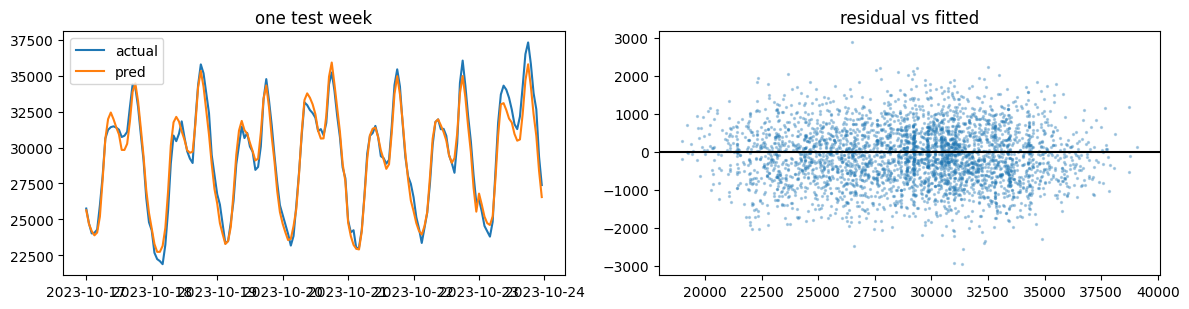

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
wk = test.iloc[24*7*10: 24*7*11]
ax[0].plot(wk["time"], wk[target], label="actual"); ax[0].plot(wk["time"], wk["pred"], label="pred"); ax[0].legend(); ax[0].set_title("one test week")
ax[1].scatter(test["pred"], test["resid"], s=2, alpha=.3); ax[1].axhline(0, c="k"); ax[1].set_title("residual vs fitted")
plt.tight_layout()

## A non-linear comparison

Trees learn the hour profile and the temperature kink without hand-made features. Keep `n_estimators` small in an interview; the point is comparison, not tuning. `feature_importances_` is impurity-based (biased toward high-cardinality/continuous features); `permutation_importance` on the *test* set is the more honest one.

In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
rf = RandomForestRegressor(n_estimators=60, min_samples_leaf=5, n_jobs=-1, random_state=0).fit(X_train, y_train)
gb = GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=0).fit(X_train, y_train)
pd.DataFrame({"random forest": metrics(y_test, rf.predict(X_test)),
              "gradient boosting": metrics(y_test, gb.predict(X_test)),
              "ols + interactions": metrics(y_test, m_int.predict(te[feat_int]))}).T.round(3)

,rmse,mae,r2,mape,bias
random forest,821.564,657.956,0.956,0.023,151.373
gradient boosting,804.119,642.686,0.958,0.023,141.863
ols + interactions,769.064,614.401,0.962,0.022,109.073


In [21]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(gb, X_test, y_test, n_repeats=5, random_state=0, scoring="neg_root_mean_squared_error")
pd.DataFrame({"impurity_importance": gb.feature_importances_,
              "perm_importance (RMSE increase)": pi.importances_mean}, index=features).sort_values("perm_importance (RMSE increase)", ascending=False).round(3)

,impurity_importance,perm_importance (RMSE increase)
hour,0.700,4861.010
hdd,0.130,704.752
temp_c,0.097,472.658
dow,0.029,264.331
weekend,0.027,248.512
solar_wm2,0.013,22.644
month,0.005,1.326
cdd,0.000,0.450
wind_ms,0.000,0.334


**Pitfall:** the tree models did not use the same "weekend x hour" information explicitly, yet compete with the linear model - because trees find interactions themselves. But they cannot extrapolate: a temperature colder than anything in training gets the same prediction as the coldest training hour.

## What to say when R² looks too good

Out-of-sample R² of 0.99 on an hourly forecast should trigger these checks, in order:

1. **Is a lagged copy of the target in the features?** `shift(0)`, `rolling()` without `shift(1)`, a "daily mean" that includes the current hour, a merge that attached tomorrow's row.
2. **Is the split really chronological?** Any `shuffle=True`, `KFold` default, or `sample()` before splitting.
3. **Was anything fitted on the full data?** Scaler, imputer, PCA, target encoding - `fit_transform(X)` before the split.
4. **Does the naive baseline also score 0.98?** Then 0.99 is not impressive; report the improvement over naive.
5. **Is the target trivially predictable at this horizon?** One-hour-ahead load with lag-1 features *is* R² 0.98. Ask what horizon the business needs.
6. **Look at coefficients.** A coefficient of ~1 on one feature and ~0 on everything else is a leak signature.
7. **Look at the worst residuals.** If they cluster around data gaps, holidays or the end of the sample, the data is the problem.

Say it out loud: "That is better than I expected; before I trust it I want to check for leakage."

## Quick reference

| Task | Call |
|---|---|
| Split by time | `split = int(len(df)*0.8); df.iloc[:split], df.iloc[split:]` |
| Fit / predict | `m = LinearRegression().fit(X_tr, y_tr); m.predict(X_te)` |
| Metrics | `root_mean_squared_error`, `mean_absolute_error`, `r2_score` |
| Coefs with names | `pd.Series(m.coef_, index=features).sort_values()` |
| Regularised | `make_pipeline(StandardScaler(), Ridge(alpha=1.0))` |
| One-hot quick | `pd.get_dummies(df["hour"], prefix="h", dtype=float)` |
| Baseline | `DummyRegressor(strategy="mean")`, `y.shift(24)` |
| Importance | `permutation_importance(m, X_te, y_te, scoring=...)` |